In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
superstore_df = pd.read_csv("superstore.csv")

In [4]:
superstore_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
superstore_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,9/11/2013,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,9/11/2013,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11/10/2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11/10/2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
superstore_df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Data Cleaning

#### 1. Check for missing values

In [7]:
superstore_df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

#### 2. Remove duplicate rows

In [8]:
superstore_df = superstore_df.drop_duplicates()

#### 3. Convert 'Order Date' to proper date format

In [10]:
superstore_df["Order Date"] = pd.to_datetime(superstore_df["Order Date"], errors = "coerce")

#### 4. Extract Month and Year as new columns (useful for trend charts later)

In [12]:
superstore_df['Month'] = superstore_df['Order Date'].dt.month_name()
superstore_df['Year'] = superstore_df['Order Date'].dt.year

### Exploratory Data Analysis (EDA)

#### --- KPIs ---

In [15]:
total_sales = superstore_df['Sales'].sum()
total_profit = superstore_df['Profit'].sum()
avg_sales = superstore_df['Sales'].mean()

In [16]:
print(f"Total Sales:   ${total_sales:,.2f}")
print(f"Total Profit:  ${total_profit:,.2f}")
print(f"Average Sale:  ${avg_sales:,.2f}")


Total Sales:   $2,297,200.86
Total Profit:  $286,397.02
Average Sale:  $229.86


####  Q1: Which category generates the highest sales? 

In [19]:
category_sales = superstore_df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("\nSales by Category:\n", category_sales)


Sales by Category:
 Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


####  Q2: Which region is most profitable? 

In [21]:
region_profit = superstore_df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("\nProfit by Region:\n", region_profit)


Profit by Region:
 Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


####  Q3: Monthly sales trends 

In [22]:
monthly_sales = superstore_df.groupby('Month')['Sales'].sum().sort_values(ascending=False)
print("\nMonthly Sales:\n", monthly_sales)


Monthly Sales:
 Month
August       94915.5305
March        93311.8796
February     92532.3740
September    82234.1036
April        75368.0000
May          71893.2540
January      71470.2572
December     69188.9217
November     69172.3135
June         55960.8810
October      55032.9850
July         54379.1368
Name: Sales, dtype: float64


####  Q4: Top 10 best-performing products 

In [23]:
top_products = superstore_df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Products:\n", top_products)


Top 10 Products:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


### Visualizations

####  Chart 1: Sales by Category (Seaborn) 

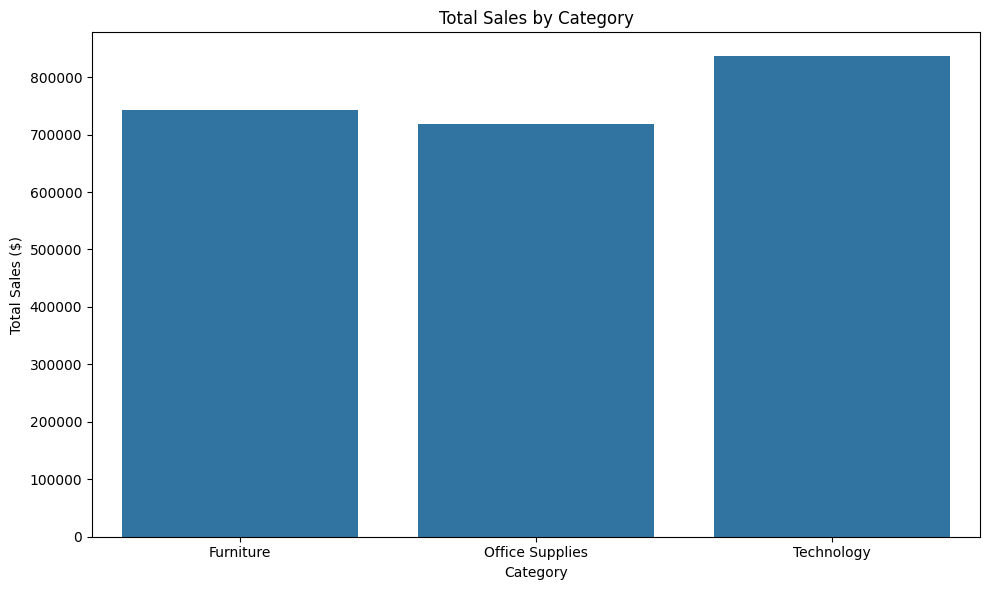

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sales', data=superstore_df, estimator=sum, errorbar=None)
plt.title('Total Sales by Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

####  Chart 2: Monthly Sales Trend 
##### Sort months in calendar order

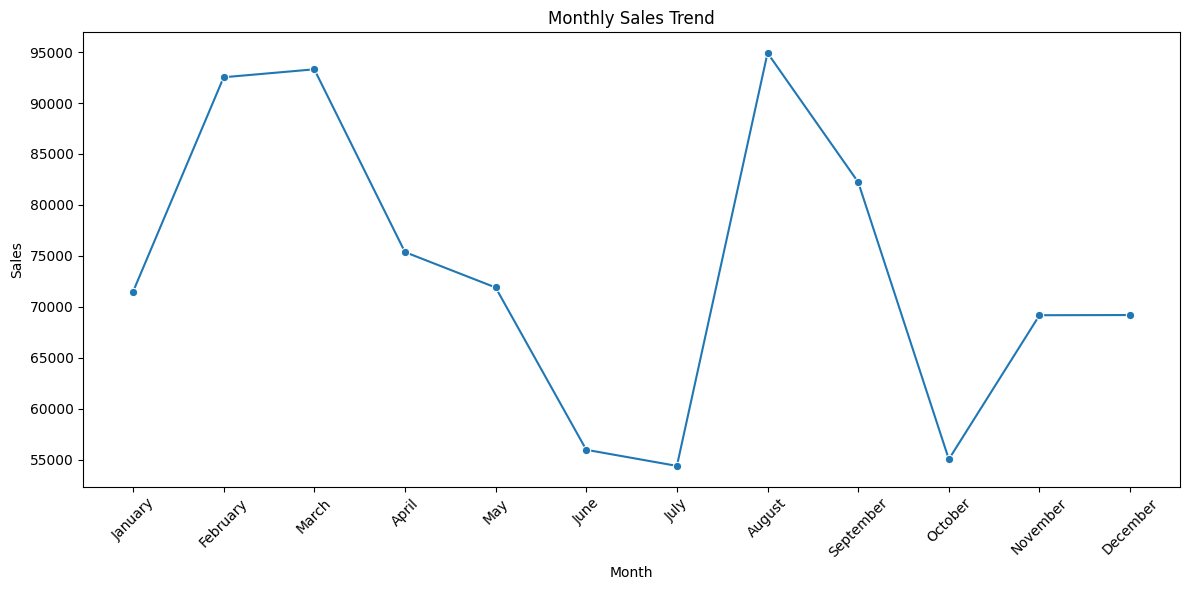

In [30]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_df = superstore_df.groupby('Month')['Sales'].sum().reindex(month_order).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Sales', data=monthly_df, marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.tight_layout()
plt.show()

####  Chart 3: Interactive Plotly Bar Chart 

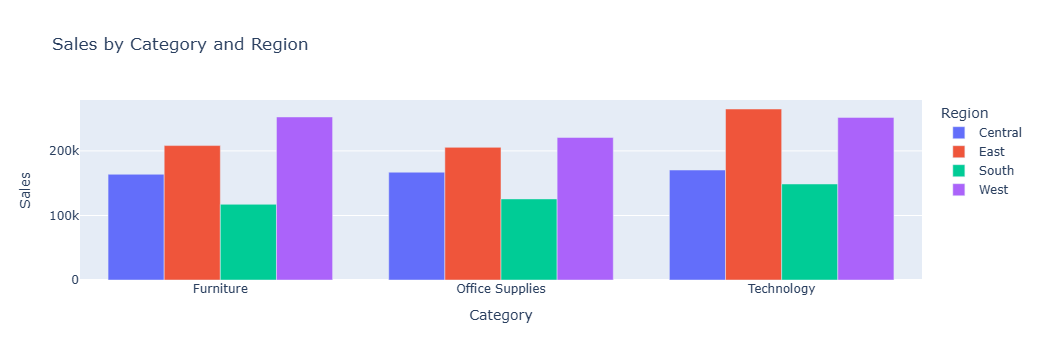

In [31]:
fig = px.bar(
    superstore_df.groupby(['Category', 'Region'])['Sales'].sum().reset_index(),
    x='Category',
    y='Sales',
    color='Region',
    barmode='group',
    title='Sales by Category and Region'
)
fig.show()